In [1]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2026-03-16 15:55:03--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  4.00MB/s    in 0.2s    

2026-03-16 15:55:03 (4.00 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [3]:
df.head(5)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]

In [5]:
df.head(5)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

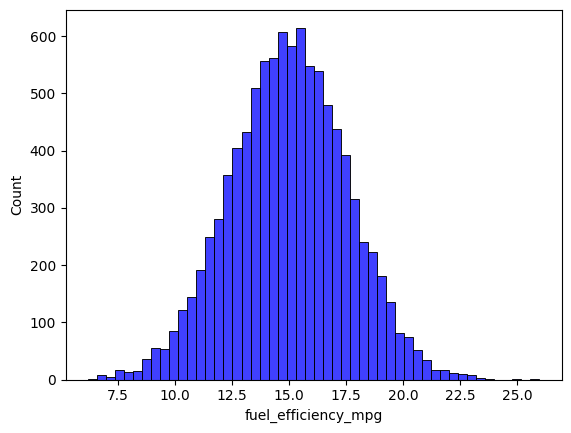

In [7]:
sns.histplot(df['fuel_efficiency_mpg'],color='blue',bins=50)

## No long tail

In [8]:
# finding columns with missing values
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Answer Q1: horsepower 

In [9]:
df['horsepower'].describe()

count    8996.000000
mean      149.657292
std        29.879555
min        37.000000
25%       130.000000
50%       149.000000
75%       170.000000
max       271.000000
Name: horsepower, dtype: float64

# Answer Q2: median: 149

In [16]:
n_val = round(len(df)*20/100)
n_test = round(len(df)*20/100)
n_train = len(df)-(n_val+n_test)
n= len(df)

In [15]:
print(n_test)
print(n_val)
print(n_train)

1941
1941
5822


In [17]:
idx = np.array(np.arange(0,n))
np.random.seed(42)
np.random.shuffle(idx)
print(idx)

[ 483 7506 8795 ... 5390  860 7270]


In [22]:
idx_train = idx[0:n_train]
idx_val = idx[n_train:n_train+n_val]
idx_test = idx[n_train+n_val:n]
print(len(idx_train)+len(idx_val)+len(idx_test))
print(n)

9704
9704


In [23]:
df_train=df.iloc[idx_train]
df_val=df.iloc[idx_val]
df_test=df.iloc[idx_test]